In [1]:
import pandas as pd
import json

In [ ]:
# from https://www.time.ir/event-year
# https://api.time.ir/v1/event/fa/events/yearlycalendar?year=1406

cals = json.load(open('output-cals.json'))

output-cals.json :

```json
{
    "1405":  { 
        // API response as json
    },
    ...
}

```


In [3]:
cals.keys()

dict_keys(['1406', '1407', '1408', '1409', '1410'])

In [4]:
year_date = dict()

for year, yearcal in cals.items():
    for i in range(12):
        m = yearcal['data'][i]
        print(m['year'],'/',m['month'])
        sh_year = m['year']
        sh_month = m['month']

        for mm in m['calendar_detail_list']:
            if mm['base'] == 1:
                wc_years = []
                wc_months = []
                for mmm in mm['month_list']:
                    wc_years.append(mmm['year'])
                    wc_months.append(mmm['month_index'])
            if mm['base'] == 2:
                ic_years = []
                ic_months = []
                for mmm in mm['month_list']:
                    ic_years.append(mmm['year'])
                    ic_months.append(mmm['month_index'])

        print(wc_months,wc_years)
        print(ic_months,ic_years)
        ic_months+=[ic_months[-1]%12+1]
        ic_years+=[ic_years[-1] if ic_months[-1]!=1 else ic_years[-1]+1]
        
        
        wc_ = 0
        ic_ = 0
        wd = -1
        for day in m['day_list']:
            wd+=1
            wd%=7
            if day['enabled']:
                sh_day = day['index_in_base1']
                wc_day = day['index_in_base2']
                ic_day = day['index_in_base3']

                if sh_day!=1:
                    wc_ += 1 if wc_day == 1 else 0
                    ic_ += 1 if ic_day == 1 else 0


                dict_ = { f"{sh_year}-{sh_month}-{sh_day}": {
                    "weekday":wd,
                    "sh": [
                        sh_year,
                        sh_month,
                        sh_day
                    ],
                    "wc": [
                        wc_years[wc_],
                        wc_months[wc_],
                        wc_day
                    ],
                    "ic": [
                        ic_years[ic_],
                        ic_months[ic_],
                        ic_day
                    ]}
                }
                year_date.update(dict_)

1406 / 1
[3, 4] [2027, 2027]
[10, 11] [1448, 1448]
1406 / 2
[4, 5] [2027, 2027]
[11, 12] [1448, 1448]
1406 / 3
[5, 6] [2027, 2027]
[12, 1] [1448, 1448]
1406 / 4
[6, 7] [2027, 2027]
[1, 2] [1449, 1449]
1406 / 5
[7, 8] [2027, 2027]
[2, 3] [1449, 1449]
1406 / 6
[8, 9] [2027, 2027]
[3, 4] [1449, 1449]
1406 / 7
[9, 10] [2027, 2027]
[4, 5] [1449, 1449]
1406 / 8
[10, 11] [2027, 2027]
[5, 6] [1449, 1449]
1406 / 9
[11, 12] [2027, 2027]
[6, 7] [1449, 1449]
1406 / 10
[12, 1] [2027, 2028]
[7, 8] [1449, 1449]
1406 / 11
[1, 2] [2028, 2028]
[8, 9] [1449, 1449]
1406 / 12
[2, 3] [2028, 2028]
[9, 10] [1449, 1449]
1407 / 1
[3, 4] [2028, 2028]
[10, 11] [1449, 1449]
1407 / 2
[4, 5] [2028, 2028]
[11, 12] [1449, 1449]
1407 / 3
[5, 6] [2028, 2028]
[12, 1] [1449, 1449]
1407 / 4
[6, 7] [2028, 2028]
[1, 2] [1450, 1450]
1407 / 5
[7, 8] [2028, 2028]
[2, 3] [1450, 1450]
1407 / 6
[8, 9] [2028, 2028]
[3, 4] [1450, 1450]
1407 / 7
[9, 10] [2028, 2028]
[5, 6] [1450, 1450]
1407 / 8
[10, 11] [2028, 2028]
[6, 7] [1450, 145

In [5]:
len(year_date)

1826

In [6]:
df_list = []
for k,d in year_date.items():
    df_list.append([d['weekday'],d['sh'][1],d['wc'][1],d['ic'][1]])

df=pd.DataFrame(df_list)
df.head()

,0,1,2,3
0,1,1,3,10
1,2,1,3,10
2,3,1,3,10
3,4,1,3,10
4,5,1,3,10


<Axes: >

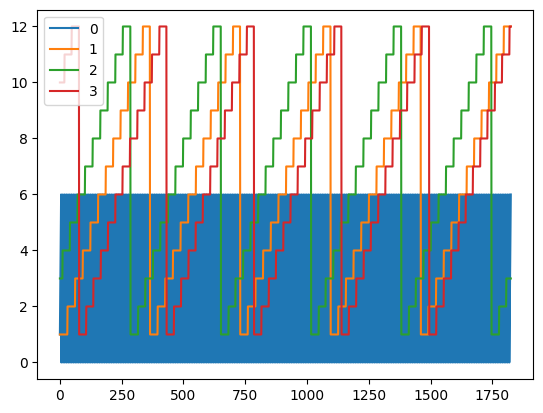

In [7]:
df.plot()

In [8]:
json.dump(year_date,open('output-data.json','w'))